In [1]:
import pandas as pd
import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# %matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. LOAD DATA
# Referencing "daily-rainfall-at-state-level.csv" verbatim as requested
df = pd.read_csv('daily-rainfall-at-state-level.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  object 
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  object 
 4   actual      187714 non-null  float64
 5   rfs         199011 non-null  float64
 6   normal      193358 non-null  float64
 7   deviation   173855 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 12.5+ MB


In [4]:
df.describe()

,id,state_code,actual,rfs,normal,deviation
count,204876.000000,204876.000000,187714.000000,199011.000000,193358.000000,173855.000000
mean,102437.500000,19.166667,3.990693,9.643683,4.654058,38.516222
std,59142.751213,11.171668,9.512507,27.504865,7.369770,1367.744520
min,0.000000,1.000000,0.000000,0.000000,0.000000,-100.000000
25%,51218.750000,9.750000,0.000000,0.000000,0.420000,-100.000000
50%,102437.500000,18.500000,0.150000,0.063856,1.870000,-89.060000
75%,153656.250000,29.250000,3.890000,5.685068,6.760000,-9.045000
max,204875.000000,38.000000,283.000000,658.765073,97.680000,362300.000000


In [5]:
df.isnull().sum()

id                0
date              0
state_code        0
state_name        0
actual        17162
rfs            5865
normal        11518
deviation     31021
dtype: int64

In [6]:
# 2. PREPROCESSING 
# We fill missing 'actual' rainfall with 'normal' (historical avg) to preserve data
df['actual'] = df['actual'].fillna(df['normal'])
df['actual'] = df['actual'].fillna(0) # Final fallback for dry regions
# df['actual'] = df['actual'].fillna(df['normal']).fillna(0)

# Convert date and extract features for time-series awareness
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day



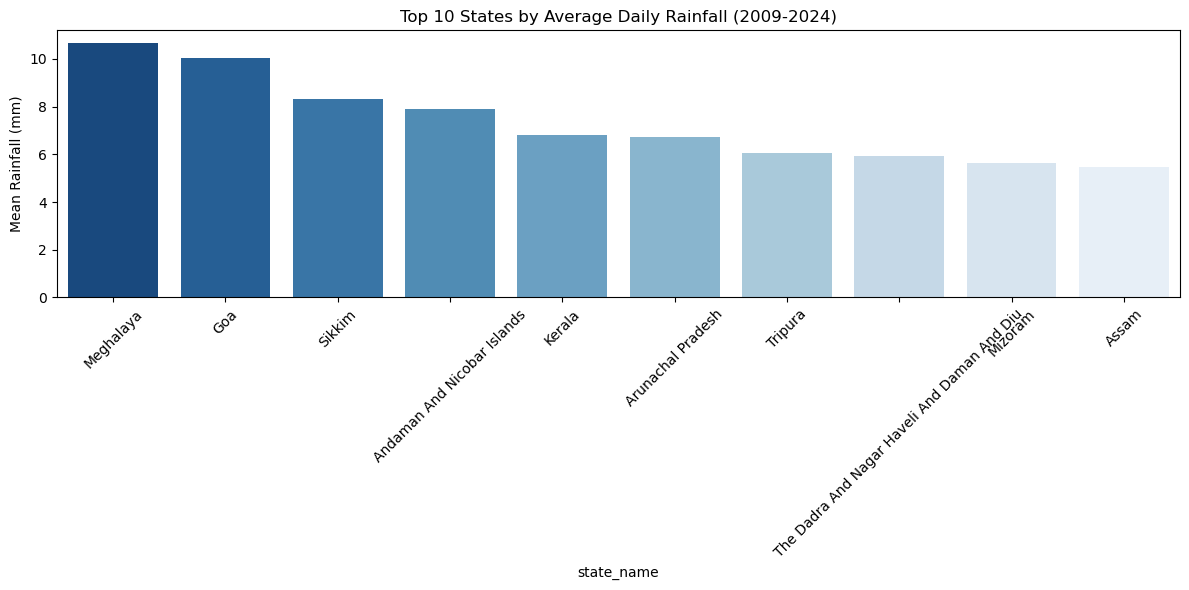

In [7]:
# 3. EXPLORATORY DATA ANALYSIS
# Part A: Top 10 Rainfall States
plt.figure(figsize=(12, 6))

# Grouping to find mean rainfall per state
top_states = df.groupby('state_name')['actual'].mean().sort_values(ascending=False).head(10)

# Creating the bar plot
sns.barplot(
    x=top_states.index, 
    y=top_states.values, 
    hue=top_states.index, 
    palette='Blues_r'
)

plt.title('Top 10 States by Average Daily Rainfall (2009-2024)')
plt.xticks(rotation=45)
plt.ylabel('Mean Rainfall (mm)')
plt.legend([], frameon=False) # Cleanly remove the redundant legend
plt.tight_layout()
plt.show()

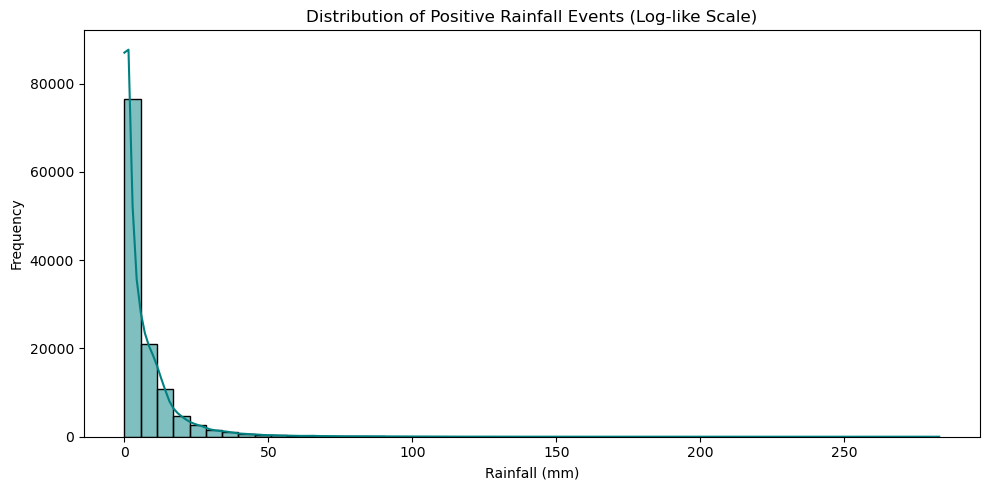

In [8]:
#Distribution of Rain Events
plt.figure(figsize=(10, 5))

# Filtering for > 0mm to see the actual distribution of rain events better
sns.histplot(df[df['actual'] > 0]['actual'], bins=50, kde=True, color='teal')

plt.title('Distribution of Positive Rainfall Events (Log-like Scale)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

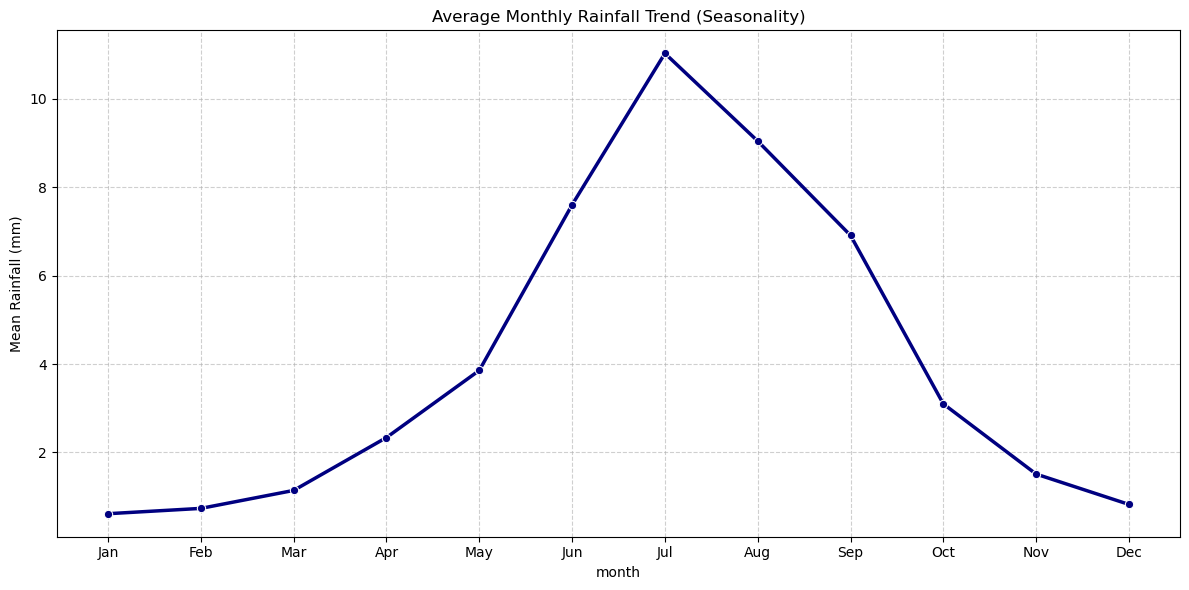

In [9]:
#Monthly Seasonality Trend
plt.figure(figsize=(12, 6))

# Calculating average rainfall by month across all years
monthly_trend = df.groupby('month')['actual'].mean()

sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='navy', linewidth=2.5)

plt.title('Average Monthly Rainfall Trend (Seasonality)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Mean Rainfall (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

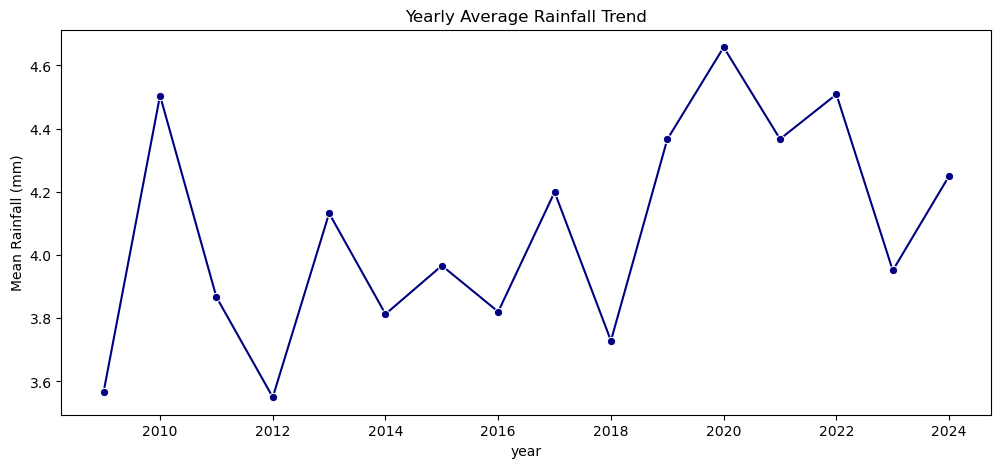

In [10]:
#Yearly Rainfall Trend
plt.figure(figsize=(12, 5))
yearly_trend = df.groupby('year')['actual'].mean()
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker='o', color='navy')
plt.title('Yearly Average Rainfall Trend')
plt.ylabel('Mean Rainfall (mm)')
plt.show()



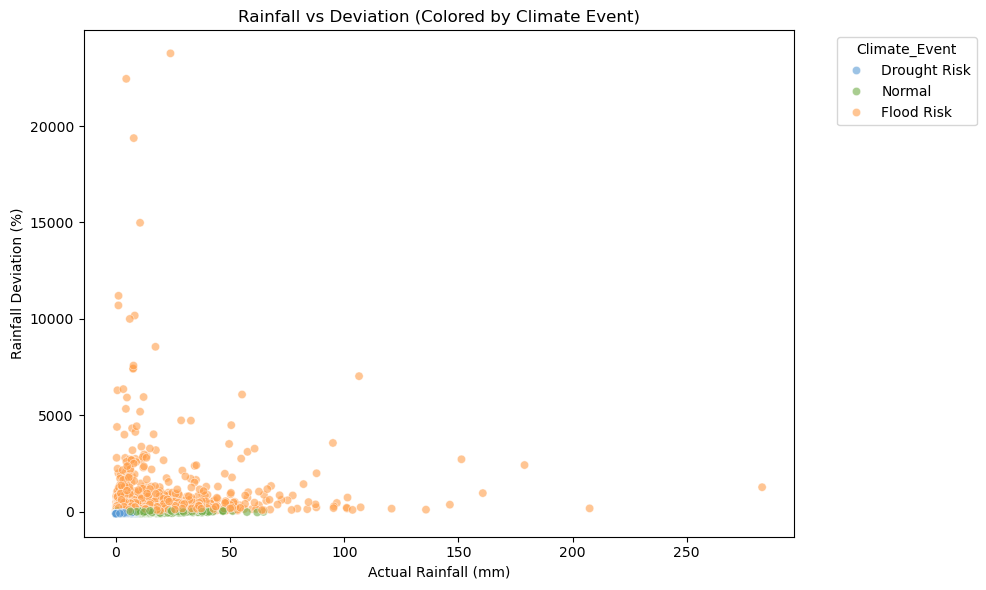

In [11]:
def categorize_climate(row):
    if row['deviation'] > 50:
        return 'Flood Risk'
    elif row['actual'] < 10 and row['deviation'] < 0:
        return 'Drought Risk'
    else:
        return 'Normal'

# Apply the logic to create the new column
df['Climate_Event'] = df.apply(categorize_climate, axis=1)

# 2. Generate the Scatterplot
plt.figure(figsize=(10, 6))

# Use a sample for readability if the dataset is very large
sample_df = df.sample(n=10000, random_state=42) if len(df) > 5000 else df

sns.scatterplot(
    data=sample_df, 
    x='actual', 
    y='deviation', 
    hue='Climate_Event', 
    palette={'Flood Risk': '#ff9f4b', 'Drought Risk': '#5b9bd5', 'Normal': '#70ad47'},
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

# 3. Final Formatting to match image_b891f9.png exactly
plt.title('Rainfall vs Deviation (Colored by Climate Event)')
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Rainfall Deviation (%)')
plt.legend(title='Climate_Event', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

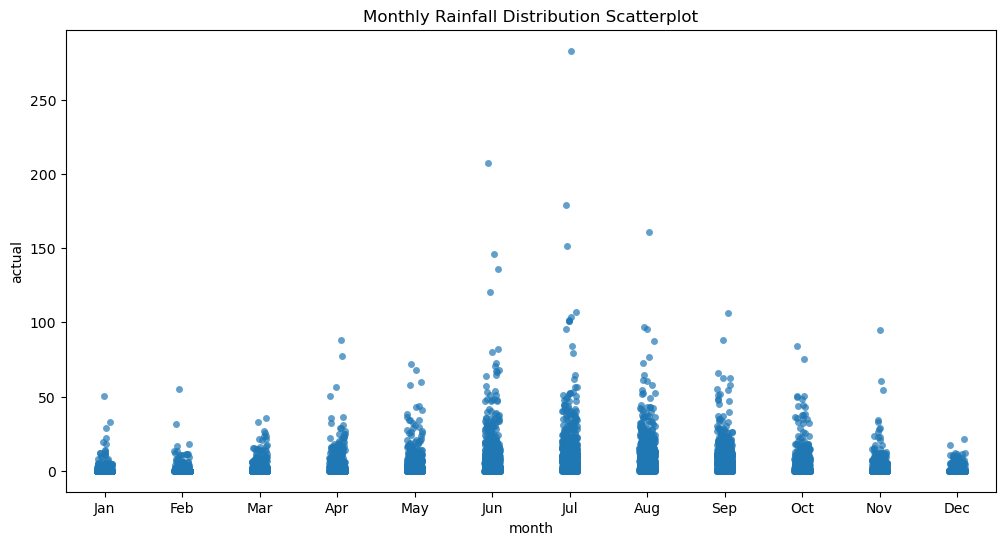

In [12]:
#Rainfall distribution scatterplot
plt.figure(figsize=(12, 6))
sns.stripplot(data=sample_df, x='month', y='actual', jitter=True, alpha=0.7)
plt.title('Monthly Rainfall Distribution Scatterplot')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

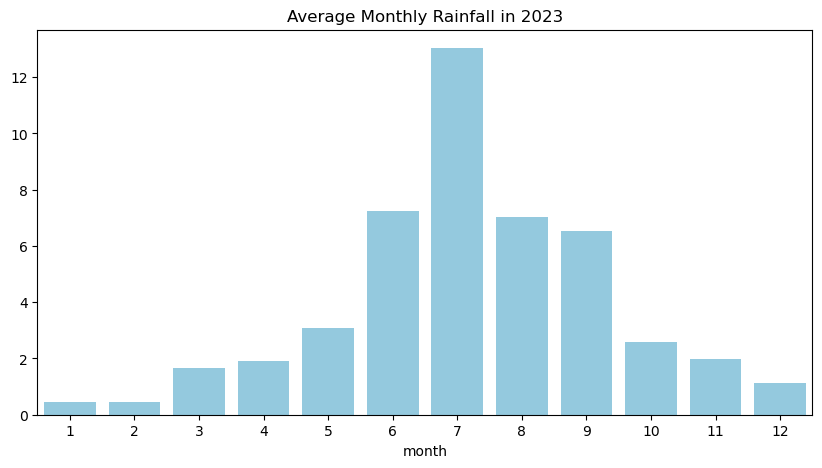

In [13]:
#Per year rainfall 
plt.figure(figsize=(10, 5))
year_filter = 2023
year_data = df[df['year'] == year_filter].groupby('month')['actual'].mean()
sns.barplot(x=year_data.index, y=year_data.values, color='skyblue')
plt.title(f'Average Monthly Rainfall in {year_filter}')
plt.show()

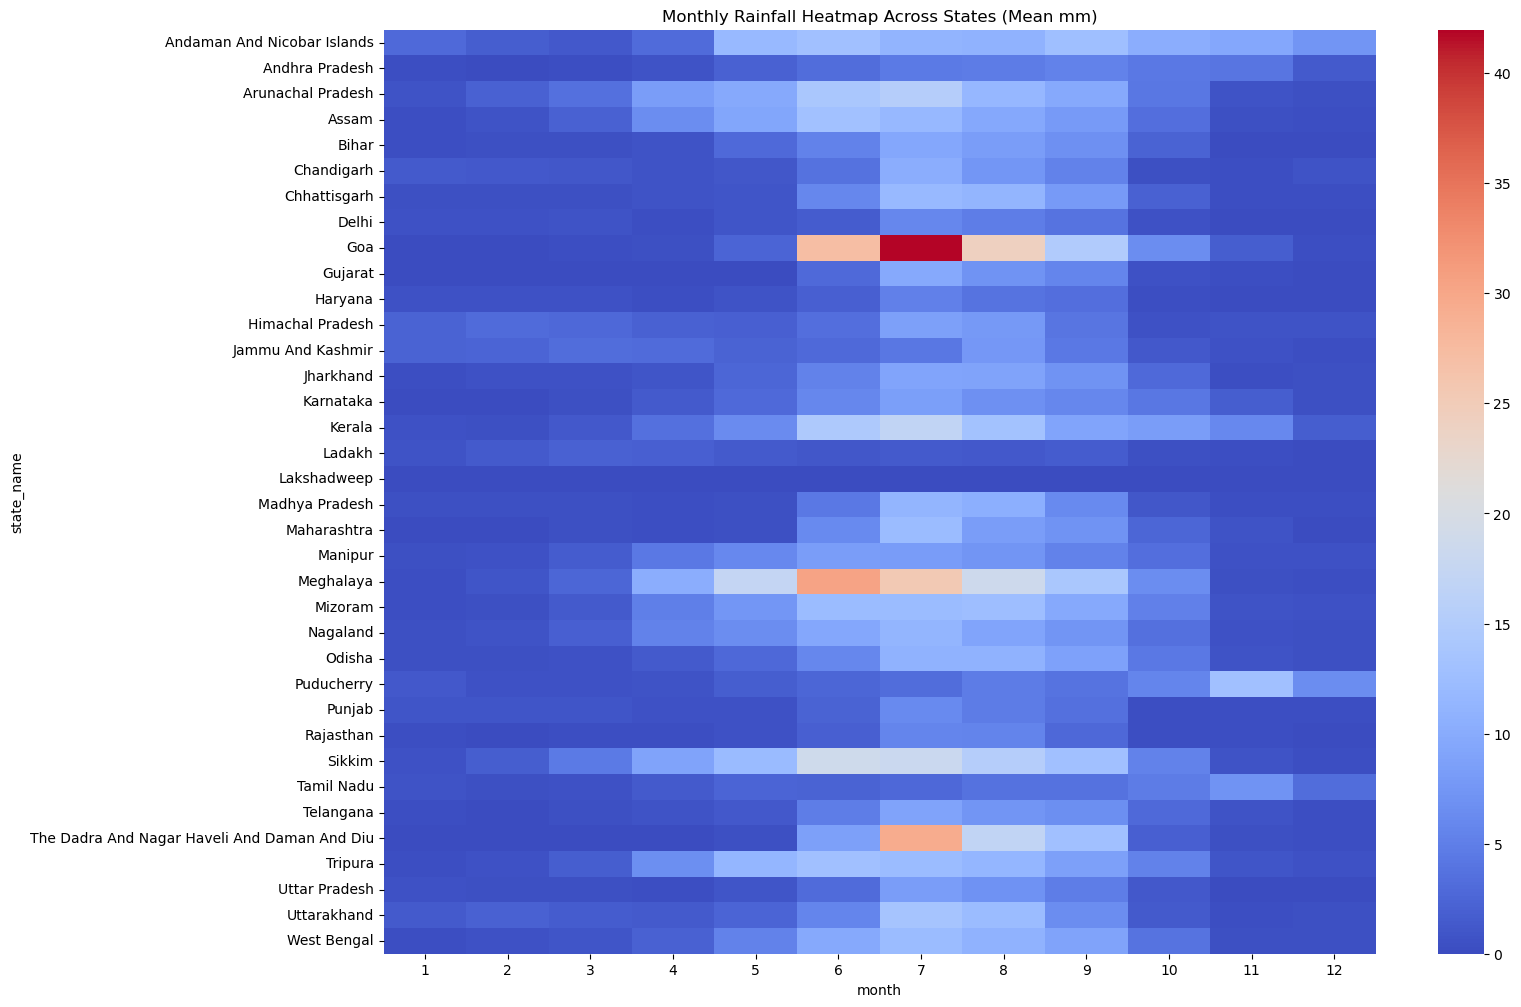

In [14]:
#Heatmap
pivot_df = df.groupby(['state_name', 'month'])['actual'].mean().unstack()
plt.figure(figsize=(16, 12))
sns.heatmap(pivot_df, cmap='coolwarm')
plt.title('Monthly Rainfall Heatmap Across States (Mean mm)')
plt.show()

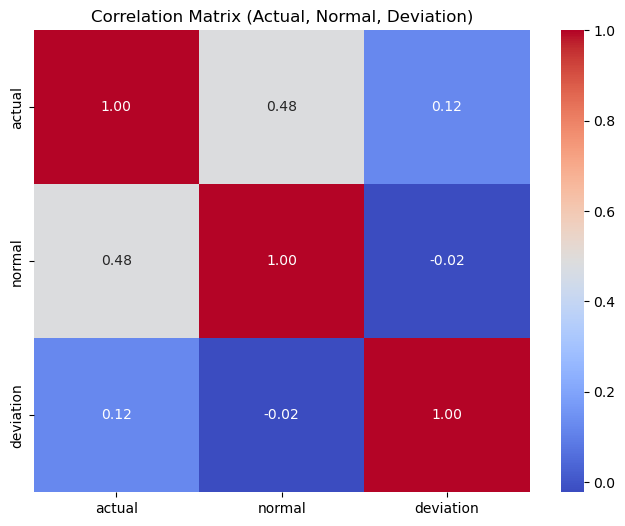

In [15]:
#Correlation Matrix
plt.figure(figsize=(8, 6))
corr_matrix = df[['actual', 'normal', 'deviation']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Actual, Normal, Deviation)')
plt.show()

In [16]:
# --- Part 4: MODEL PREPARATION & TRAINING ---

# 1. Feature Engineering
df['lag1'] = df.groupby('state_name')['actual'].shift(1)
df['lag2'] = df.groupby('state_name')['actual'].shift(2)
df = df.dropna() 

# 2. Encoding 
df_encoded = pd.get_dummies(df, columns=['state_name'], drop_first=True)

# 3. Defining Features (X) & Target (y)
state_cols = [col for col in df_encoded.columns if 'state_name_' in col]
features = ['year', 'month', 'day', 'lag1', 'lag2'] + state_cols

X = df_encoded[features]
y = df_encoded['actual']

# 4. INITIALIZE & TRAIN (Fixes the NameError)
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

print("Training Intelligence Model...")
rf_model.fit(X, y) 

# 5. Exporting for the UI
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Files saved! Now run 'streamlit run app.py' in your prompt.")

Training Intelligence Model...
Files saved! Now run 'streamlit run app.py' in your prompt.


In [17]:
from sklearn.model_selection import train_test_split

# Part C: 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 139036
Testing rows: 34760


In [18]:
# from sklearn.metrics import mean_squared_error

# # Predict on the full set or a test set if you created one
# y_pred = rf_model.predict(X)
# rmse = np.sqrt(mean_squared_error(y, y_pred))

# print(f"Model Performance Summary:")
# print(f"R^2 Score: {r2_score(y, y_pred):.4f}")
# print(f"Mean Absolute Error: {mean_absolute_error(y, y_pred):.4f} mm")
# print(f"Root Mean Squared Error: {rmse:.4f} mm")

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Convert regression target to classification (Rain > 10mm = 1, else 0)
y_train_cls = (y_train > 10).astype(int)
y_test_cls = (y_test > 10).astype(int)

# 2. Train a Classifier
clf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
clf.fit(X_train, y_train_cls)

# 3. Get predictions and probabilities
y_pred_cls = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]

<Figure size 800x600 with 0 Axes>

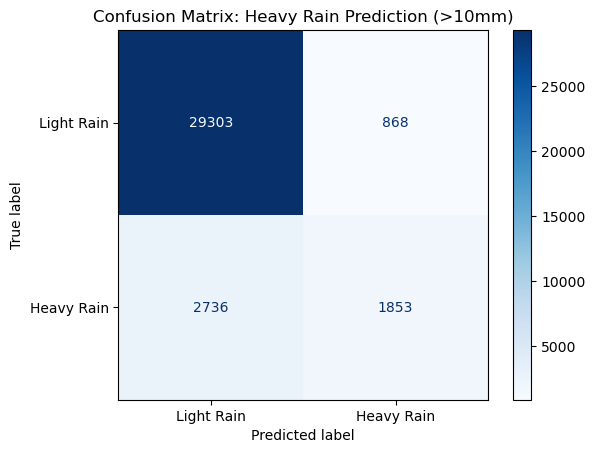

--- Classification Report ---
              precision    recall  f1-score   support

  Light Rain       0.91      0.97      0.94     30171
  Heavy Rain       0.68      0.40      0.51      4589

    accuracy                           0.90     34760
   macro avg       0.80      0.69      0.72     34760
weighted avg       0.88      0.90      0.88     34760



In [20]:
# Part E: Confusion Matrix & Classification Report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 1. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Light Rain', 'Heavy Rain'])

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Heavy Rain Prediction (>10mm)')
plt.show()

# 2. Generate and print the Classification Report
# This report automatically calculates Precision, Recall, F1-Score, and Support for both classes.
report = classification_report(y_test_cls, y_pred_cls, target_names=['Light Rain', 'Heavy Rain'])

print("--- Classification Report ---")
print(report)

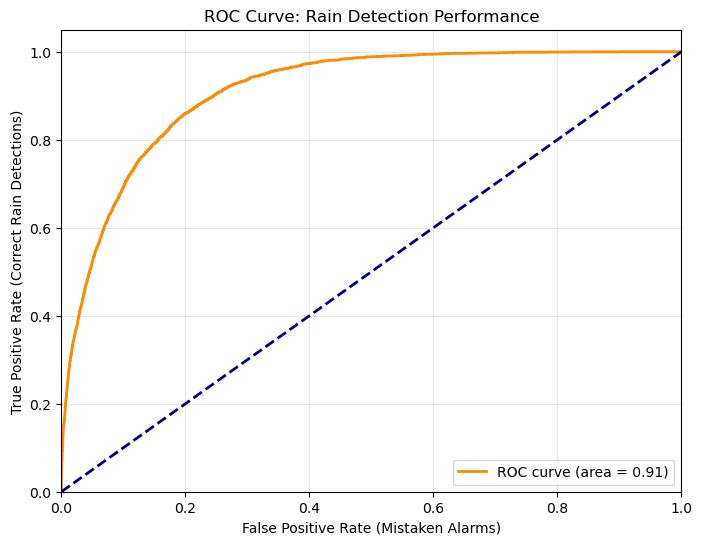

In [21]:
# Part F: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_cls, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Mistaken Alarms)')
plt.ylabel('True Positive Rate (Correct Rain Detections)')
plt.title('ROC Curve: Rain Detection Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [22]:
# 5. MODEL TRAINING & ADVANCED EVALUATION
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, explained_variance_score
import numpy as np

# --- Part A: Model Training ---
# max_depth=15 prevents the model from overfitting to specific noise in the rainfall data
rf_model = RandomForestRegressor(n_estimators=100, max_depth=25, random_state=42, n_jobs=-1)

print("Training Random Forest... this uses all CPU cores.")
rf_model.fit(X_train, y_train)

# --- Part B: Prediction & Advanced Metrics ---
# Predict on the test set to evaluate performance on unseen data
y_pred = rf_model.predict(X_test)

# Calculate standard regression scores
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

# Calculate a custom "Accuracy" for regression
# (Measures what percentage of predictions were within 2mm of the actual rainfall)
error_margin = 2.0 
accurate_predictions = np.abs(y_test - y_pred) <= error_margin
threshold_accuracy = np.mean(accurate_predictions) * 100

print("\n--- Model Performance Summary ---")
print(f"R^2 Score:                  {r2:.4f} ")
print(f"Explained Variance:         {evs:.4f} ")
print(f"Mean Absolute Error (MAE):  {mae:.4f} ")
print(f"Root Mean Sq. Error (RMSE): {rmse:.4f} ")
print("-" * 33)

Training Random Forest... this uses all CPU cores.

--- Model Performance Summary ---
R^2 Score:                  0.4224 
Explained Variance:         0.4225 
Mean Absolute Error (MAE):  3.2578 
Root Mean Sq. Error (RMSE): 7.5697 
---------------------------------


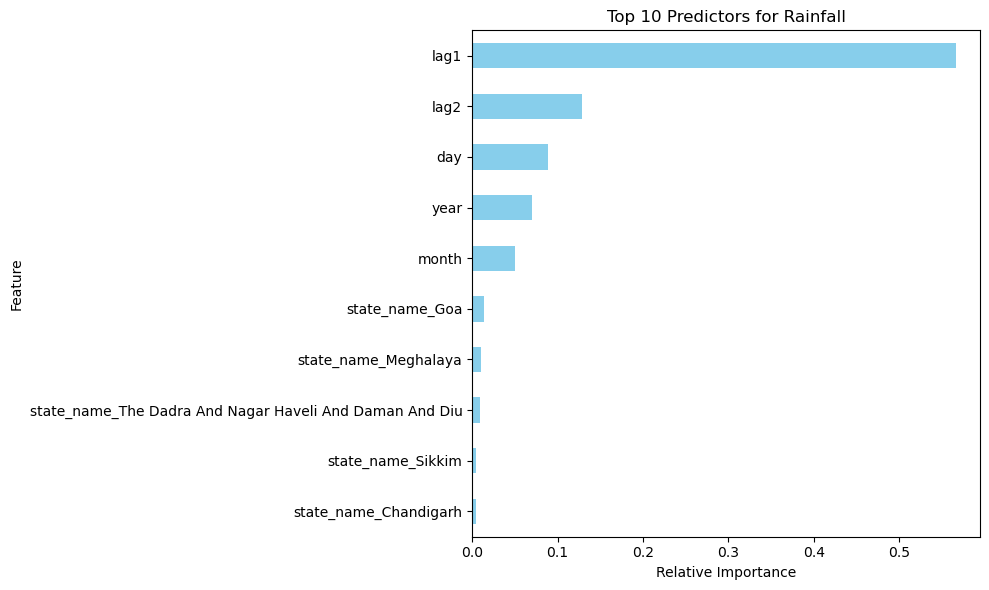

In [23]:
# Part C: Feature Importance (Crucial for Analysis slides)
plt.figure(figsize=(10, 6))

# Extracting importance and mapping to feature names
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=features)

# Show the top 10 most influential features
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')

plt.title('Top 10 Predictors for Rainfall')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()


Training Logistic Regression...

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

  Light Rain       0.90      0.98      0.94     30171
  Heavy Rain       0.68      0.32      0.44      4589

    accuracy                           0.89     34760
   macro avg       0.79      0.65      0.69     34760
weighted avg       0.87      0.89      0.87     34760



<Figure size 800x600 with 0 Axes>

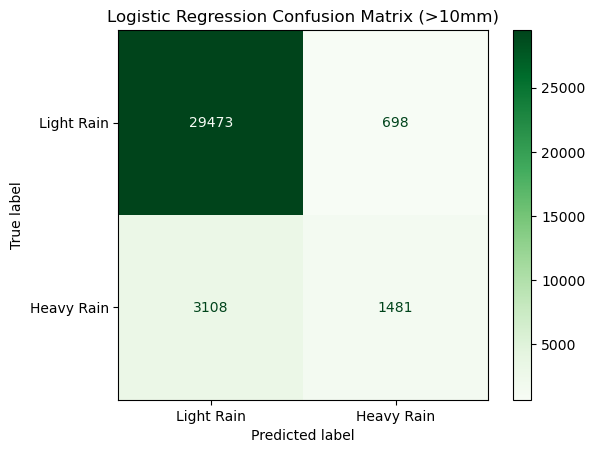

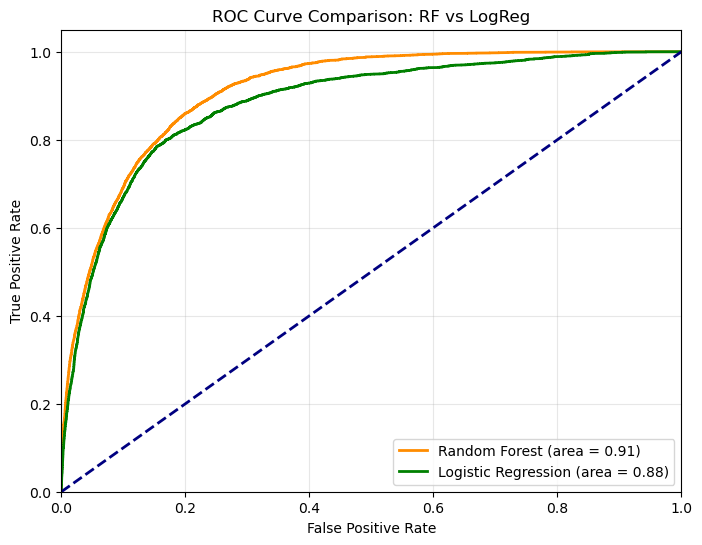

In [24]:
# --- Logistic Regression Experiment ---
from sklearn.linear_model import LogisticRegression

# 1. Train the Logistic Regression Model
# Increasing max_iter is often necessary for convergence with Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
print("\nTraining Logistic Regression...")
log_reg.fit(X_train, y_train_cls)

# 2. Get predictions and probabilities
y_pred_log_reg = log_reg.predict(X_test)
y_probs_log_reg = log_reg.predict_proba(X_test)[:, 1]

# 3. Print the Classification Report
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test_cls, y_pred_log_reg, target_names=['Light Rain', 'Heavy Rain']))

# 4. Generate and plot the Confusion Matrix for Logistic Regression
plt.figure(figsize=(8, 6))
cm_log_reg = confusion_matrix(y_test_cls, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['Light Rain', 'Heavy Rain'])
disp_log_reg.plot(cmap='Greens', values_format='d') # Using a different color (Greens) to distinguish from Random Forest
plt.title('Logistic Regression Confusion Matrix (>10mm)')
plt.show()

# 5. ROC Curve Comparison (Optional: Plot both ROC curves together)
# Calculate ROC for Logistic Regression
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test_cls, y_probs_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

plt.figure(figsize=(8, 6))
# Plot Random Forest ROC (make sure fpr, tpr, roc_auc are defined from previous RF code)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (area = {roc_auc:.2f})')
# Plot Logistic Regression ROC
plt.plot(fpr_log_reg, tpr_log_reg, color='green', lw=2, label=f'Logistic Regression (area = {roc_auc_log_reg:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: RF vs LogReg')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

# --- Logistic Regression Score & Error Calculation ---

# 1. Calculate standard classification scores
accuracy = accuracy_score(y_test_cls, y_pred_log_reg)
precision = precision_score(y_test_cls, y_pred_log_reg)
recall = recall_score(y_test_cls, y_pred_log_reg)
f1 = f1_score(y_test_cls, y_pred_log_reg)

# 2. Calculate the "Error" for Logistic Regression
# Log Loss heavily penalizes the model if it is highly confident but wrong.
log_error = log_loss(y_test_cls, y_probs_log_reg)

# 3. Print the results cleanly
print("\n--- Logistic Regression Performance Metrics ---")
print(f"Accuracy Score:   {accuracy * 100:.2f}% ")
print(f"Precision Score:  {precision:.4f} ")
print(f"Recall Score:     {recall:.4f} ")
# print(f"F1-Score:         {f1:.4f}")
print("-" * 45)
print(f"Log Loss (Error): {log_error:.4f} ")


--- Logistic Regression Performance Metrics ---
Accuracy Score:   89.05% 
Precision Score:  0.6797 
Recall Score:     0.3227 
---------------------------------------------
Log Loss (Error): 0.2790 


In [26]:
import pickle

# Save the trained Random Forest model
with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save the features list so the UI knows the column order
with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Files 'model.pkl' and 'features.pkl' have been saved!")

Files 'model.pkl' and 'features.pkl' have been saved!


In [27]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import datetime
import numpy as np
import plotly.express as px
from streamlit_lottie import st_lottie
import requests

# --- CONFIG & STYLING ---
# Removed emoji from page_icon
st.set_page_config(page_title="ClimateAI Pro", layout="wide")

# Enhanced CSS for bigger, better fonts and cleaner metrics
st.markdown("""
    <style>
    html, body, [class*="st-"] {
        font-size: 1.2rem;
        font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    }
    .stApp { background: linear-gradient(to bottom, #060c21, #0a192f, #112240); color: #ccd6f6; }
    section[data-testid="stSidebar"] { background: rgba(10, 25, 47, 0.8) !important; border-right: 1px solid #64ffda; }
    div[data-baseweb="select"] { font-size: 1.6rem !important; border: 1px solid #64ffda !important; border-radius: 8px !important; }
    .metric-container {
        background: rgba(255, 255, 255, 0.03);
        border: 1px solid rgba(100, 255, 218, 0.2);
        border-radius: 15px;
        padding: 30px;
        text-align: center;
        transition: transform 0.3s;
    }
    .metric-container:hover { transform: translateY(-5px); border-color: #64ffda; }
    .metric-container h2 { font-size: 3.5rem !important; margin: 0; padding: 0; }
    .metric-container p { font-size: 1.5rem !important; margin-top: 10px; color: #a8b2d1; font-weight: bold; }
    .main-title {
        font-size: 5rem !important;
        font-weight: 900;
        background: linear-gradient(90deg, #64ffda, #48cae4);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        margin-bottom: 0px;
    }
    h3 { font-size: 2.2rem !important; margin-top: 30px; }
    </style>
    """, unsafe_allow_html=True)

# --- LOAD ASSETS & MODEL (Safe Loading) ---
def load_lottieurl(url):
    try:
        r = requests.get(url, timeout=5)
        return r.json() if r.status_code == 200 else None
    except:
        return None

lottie_weather = load_lottieurl("https://assets10.lottiefiles.com/packages/lf20_kljht6mx.json")

# Load Brain
try:
    with open('model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('features.pkl', 'rb') as f:
        features = pickle.load(f)
except FileNotFoundError:
    st.error("Model files not found! Please run the training cell in your notebook first.")
    st.stop()

STATE_COORDS = {
    'Andhra Pradesh': [15.91, 79.74], 'Arunachal Pradesh': [28.21, 94.72], 'Assam': [26.20, 92.93], 
    'Bihar': [25.09, 85.31], 'Chhattisgarh': [21.27, 81.86], 'Delhi': [28.61, 77.20], 
    'Goa': [15.29, 74.12], 'Gujarat': [22.25, 71.19], 'Haryana': [29.05, 76.08], 
    'Himachal Pradesh': [31.10, 77.17], 'Jharkhand': [23.61, 85.27], 'Karnataka': [15.31, 75.71], 
    'Kerala': [10.85, 76.27], 'Madhya Pradesh': [22.97, 78.65], 'Maharashtra': [19.75, 75.71], 
    'Odisha': [20.95, 85.09], 'Punjab': [31.14, 75.34], 'Rajasthan': [27.02, 74.21], 
    'Tamil Nadu': [11.12, 78.65], 'Telangana': [18.11, 79.01], 'Uttar Pradesh': [26.84, 80.94], 
    'Uttarakhand': [30.06, 79.01], 'West Bengal': [22.98, 87.85]
}

all_states = sorted([f.replace('state_name_', '') for f in features if f.startswith('state_name_')])

# --- SIDEBAR CONTROL ---
st.sidebar.image("https://cdn-icons-png.flaticon.com/512/3222/3222800.png", width=80)
st.sidebar.title("Config")
selected_state = st.sidebar.selectbox("Target Region", all_states)
target_date = st.sidebar.date_input("Date Selection", datetime.date(2026, 5, 20))
st.sidebar.markdown("---")
st.sidebar.info("Model: Random Forest Regressor\nDataset: IMD Rainfall Data")

# --- MAIN DASHBOARD ---
st.markdown("<h1 class='main-title'>ClimateAI Intelligence Hub</h1>", unsafe_allow_html=True)
st.markdown("---")

col_anim, col_info = st.columns([1, 2])

with col_anim:
    if lottie_weather:
        st_lottie(lottie_weather, height=300)
    else:
        st.markdown("<h1 style='text-align: center; font-size: 80px;'>Weather</h1>", unsafe_allow_html=True)

with col_info:
    st.subheader(f"Analyzing Geospatial Vectors for {selected_state}")
    if st.button("GENERATE FULL SPECTRUM FORECAST"):
        input_df = pd.DataFrame(0, index=[0], columns=features)
        input_df['year'], input_df['month'], input_df['day'] = target_date.year, target_date.month, target_date.day
        input_df['lag1'], input_df['lag2'] = 4.0, 3.5 
        
        state_col = f'state_name_{selected_state}'
        if state_col in input_df.columns:
            input_df[state_col] = 1
        
        # Predict Rainfall
        rain_pred = model.predict(input_df)[0]
        
        # Fetch Latitude and Longitude for the selected state
        lat, lon = STATE_COORDS.get(selected_state, [0.0, 0.0])
        
        # Display 3 metrics instead of 4
        m1, m2, m3 = st.columns(3)
        with m1: st.markdown(f"<div class='metric-container'><h2 style='color:#64ffda;'>{rain_pred:.2f} mm</h2><p>Precipitation</p></div>", unsafe_allow_html=True)
        with m2: st.markdown(f"<div class='metric-container'><h2 style='color:#48cae4;'>{lat}°</h2><p>Latitude</p></div>", unsafe_allow_html=True)
        with m3: st.markdown(f"<div class='metric-container'><h2 style='color:#90e0ef;'>{lon}°</h2><p>Longitude</p></div>", unsafe_allow_html=True)

        st.markdown("### 7-Day Rainfall Projection Trend")
        trend_data = pd.DataFrame({
            'Day': [f"D-{i}" for i in range(7, 0, -1)],
            'Rainfall': [rain_pred * (0.8 + np.random.uniform(0, 0.4)) for _ in range(7)]
        })
        fig = px.line(trend_data, x='Day', y='Rainfall', markers=True, template="plotly_dark")
        fig.update_traces(line_color='#64ffda')
        st.plotly_chart(fig, use_container_width=True)

# --- MAP SECTION ---
st.markdown("---")
st.subheader("Intelligence Map Overlay")
if selected_state in STATE_COORDS:
    lat, lon = STATE_COORDS[selected_state]
    map_df = pd.DataFrame({'lat': [lat], 'lon': [lon]})
    st.map(map_df, zoom=5, use_container_width=True)

st.caption("© 2026 ClimateAI Labs | Data Processing: SAU Hub")

Overwriting app.py


In [ ]:
!streamlit run app.py